# Statistical Analysis

This notebook contains the Python code used to process the study data and perform the statistical analyses reported in the thesis.

The analysis covers objective and perceived understanding, perceived usability and usefulness, and documentation preference. The anonymized analysis data required as input for the analyses are provided separately in the thesis appendix.

## Reproducibility

The notebook can be executed from top to bottom with the appropriate input data to reproduce the statistical analyses and visualizations reported in the thesis.

The anonymized analysis data required as input are provided separately in the thesis appendix.

---
## Content
1. Datasets
    - Objective Understanding
    - Perceived Understanding
    - Perceived Usability and Usefulness
    - Documentation Preference

2. Objective Understanding
    - Shapiro-Wilk test
    - Paired-samples t-test
    - Cohen's $d_z$

3. Perceived Understanding
    - Wilcoxon signed-rank test
    - Friedman test

4. Usability and Usefulness (UMUX-LITE)
    - Wilcoxon signed-rank test

5. Documentation Preference
    - Wilcoxon signed-rank test

6. Visualizations
    - Objective Understanding
    - Perceived Understanding
    - Usability and Usefulness (UMUX-LITE)
    - Documentation Preference and Recommendation


---

# 1. Datasets
The datasets provided in the thesis appendix should be entered here as input for the subsequent analyses.

In [5]:
# Datasets to be used as input - Objective Understanding

# pipeline_sub_item = ...
# baseline_sub_item = ...

# pipeline_correctly_questions = ...
# baseline_correctly_questions = ...

In [6]:
# Datasets to be used as input - Perceived Understanding

# pu_before = ...                       # First rating of the participants before they saw the pipeline or baseline documentation

# Wilcoxon signed-rank test 
# pu_pipeline = ...                     # Pipeline rating of the participants after they saw the documentation
# pu_baseline = ...                     # Baseline rating of the participants after they saw the documentation
# pu_diff_base_pipe = ...               # BASE-PIPE

# Friedman Test – Rank-Based Data Input
# pu_conf0_ranks = ...
# pu_pipeline_ranks = ...
# pu_baseline_ranks = ...

In [7]:
# Datasets to be used as input - Usability and Usefulness (UMUX-LITE)

# umux_pipeline = ...
# umux_baseline = ...

In [8]:
# Datasets to be used as input - Documentation Preference and Recommendation

# prefer_pipeline = ...
# prefer_baseline = ...

# recommend_pipeline = ...
# recommend_baseline = ...

## 2. Objective Understanding

### Shapiro-Wilk test

In [9]:
from scipy.stats import shapiro

#correct sub items
differences = [b - p for p, b in zip(pipeline_sub_item, baseline_sub_item)]
# Shapiro-Wilk-Test
result = shapiro(differences)

print("Differenzen:", differences)
print(result)
#correct answers
differences = [b - p for p, b in zip(pipeline_correctly_questions, baseline_correctly_questions)]
# Shapiro-Wilk-Test
result = shapiro(differences)
print("Differenzen:", differences)
print(result)

Differenzen: [40.0, -8.569999999999993, 37.14, -14.290000000000006, -5.709999999999994, 5.709999999999994, 28.569999999999993, 31.43, -11.430000000000007, 80.0, -45.709999999999994, 0.0, -17.14]
ShapiroResult(statistic=np.float64(0.948971430042131), pvalue=np.float64(0.5827888252149918))
Differenzen: [66.67, -33.34, 33.34, 0.0, 0.0, 0.0, 66.67, 33.33, -33.34, 100.0, -66.67, 0.0, 0.0]
ShapiroResult(statistic=np.float64(0.9493184583420188), pvalue=np.float64(0.5879991504303604))


### Paired-samples t-test

In [10]:
from scipy.stats import ttest_rel

#correct answers
result = ttest_rel(baseline_sub_item, pipeline_sub_item)
print(result)
# Shapiro-Wilk-Test
result = ttest_rel(baseline_correctly_questions, pipeline_correctly_questions) # Diff = Baseline-Pipeline
print(result)

TtestResult(statistic=np.float64(1.0138170072667798), pvalue=np.float64(0.33067590357207377), df=np.int64(12))
TtestResult(statistic=np.float64(0.9999090025416686), pvalue=np.float64(0.33709132461814684), df=np.int64(12))


### Cohen's $d_z$

The calculation of Cohen's $d_z$ was verified using the following sources:

- **Calculation of Cohen's $d_z$:** [Lakens (2013)](https://www.frontiersin.org/journals/psychology/articles/10.3389/fpsyg.2013.00863/full)
- **Standard deviation calculation (`numpy.std(ddof=1)`):** [NumPy documentation](https://numpy.org/devdocs/reference/generated/numpy.std.html)
- **Interpretation of effect sizes:** [Cohen (1988), *Statistical Power Analysis for the Behavioral Sciences*](https://utstat.toronto.edu/~brunner/oldclass/378f16/readings/CohenPower.pdf)

Following Cohen's (1988) conventional benchmarks, the observed effect size is interpreted as small.

In [11]:
import numpy as np

# Cohen's dz
diff_sub = np.array(baseline_sub_item) - np.array(pipeline_sub_item)
diff_questions = np.array(baseline_correctly_questions) - np.array(pipeline_correctly_questions)

dz_sub = diff_sub.mean() / diff_sub.std(ddof=1)
dz_questions = diff_questions.mean() / diff_questions.std(ddof=1)

print("Cohen's dz (Normalized sub-item accuracy):", dz_sub)
print("Cohen's dz (Correctly answered questions):", dz_questions)

Cohen's dz (Normalized sub-item accuracy): 0.2811822464336786
Cohen's dz (Correctly answered questions): 0.27732485995861833


---
## 3. Perceived Understanding

### Wilcoxon signed-rank test

In [12]:
from scipy.stats import wilcoxon
import numpy as np

result = wilcoxon(pu_diff_base_pipe)

print(result)

WilcoxonResult(statistic=np.float64(9.0), pvalue=np.float64(1.0))


In [13]:
import pingouin as pg

pg.wilcoxon(pu_baseline, pu_pipeline)

,W_val,alternative,p_val,RBC,CLES
Wilcoxon,9.0,two-sided,1.0,-0.142857,0.467456


### Friedman Test

In [14]:
from scipy.stats import friedmanchisquare



result = friedmanchisquare(pu_conf0_ranks,
                  pu_pipeline_ranks,
                  pu_baseline_ranks)

chi2 = result.statistic
p = result.pvalue

n = len(pu_conf0_ranks)      # 13 Teilnehmer
k = 3               # drei Messzeitpunkte

kendalls_w = chi2 / (n * (k - 1))

print(f"Chi² = {chi2:.3f}")
print(f"p = {p:.3f}")
print(f"Kendall's W = {kendalls_w:.3f}")

Chi² = 3.697
p = 0.157
Kendall's W = 0.142


---

## 4. Usability and Usefulness (UMUX-LITE)

### Wilcoxon signed-rank test

In [15]:
from scipy.stats import wilcoxon
import pingouin as pg

print(wilcoxon(umux_baseline, umux_pipeline))
pg.wilcoxon(umux_baseline, umux_pipeline)

WilcoxonResult(statistic=np.float64(5.5), pvalue=np.float64(0.0390625))


,W_val,alternative,p_val,RBC,CLES
Wilcoxon,5.5,two-sided,0.039062,0.755556,0.695266


---
## 5. Documentation Preference and Recommendation

### Wilcoxon Signed-Rank Test

In [16]:
import pingouin as pg
from scipy.stats import wilcoxon

print("Preference for future use")

print(wilcoxon(prefer_baseline, prefer_pipeline))
pg.wilcoxon(prefer_baseline, prefer_pipeline)

Preference for future use
WilcoxonResult(statistic=np.float64(13.0), pvalue=np.float64(0.171875))


,W_val,alternative,p_val,RBC,CLES
Wilcoxon,13.0,two-sided,0.171875,0.527273,0.639053


In [17]:
import pingouin as pg
from scipy.stats import wilcoxon

print("\nRecommendation to others")

print(wilcoxon(recommend_baseline, recommend_pipeline))
pg.wilcoxon(recommend_baseline, recommend_pipeline)


Recommendation to others
WilcoxonResult(statistic=np.float64(11.0), pvalue=np.float64(0.1015625))


,W_val,alternative,p_val,RBC,CLES
Wilcoxon,11.0,two-sided,0.101562,0.6,0.64497


---
## 6. Visualizations

### Objective Understanding

In [18]:
datasets = [
    (pipeline_correctly_questions, baseline_correctly_questions),
    (pipeline_sub_item, baseline_sub_item)
]

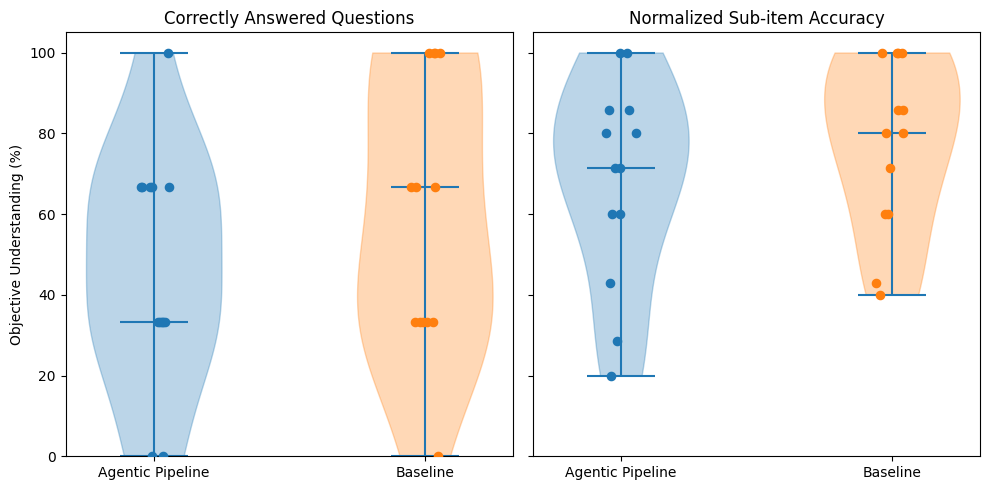

In [19]:
# ============================================================
# Objective Understanding
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Colors
PIPELINE_COLOR = "#1f77b4"   # Matplotlib standard blue
BASELINE_COLOR = "#ff7f0e"   # Matplotlib standard orange

# ============================================================
# Create two violin plots
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    sharey=True
)

rng = np.random.default_rng(42)


titles = [
    "Correctly Answered Questions",
    "Normalized Sub-item Accuracy"
]


for ax, (pipeline, baseline), title in zip(axes, datasets, titles):

    # Violin plots
    parts = ax.violinplot(
        [pipeline, baseline],
        positions=[1, 2],
        showmedians=True,
        showextrema=True
    )

    # Set violin colors
    for body, color in zip(
        parts["bodies"],
        [PIPELINE_COLOR, BASELINE_COLOR]
    ):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.3)

    # Individual participant points
    for x, values, color in zip(
        [1, 2],
        [pipeline, baseline],
        [PIPELINE_COLOR, BASELINE_COLOR]
    ):

        jitter = rng.uniform(-0.06, 0.06, len(values))

        ax.scatter(
            np.full(len(values), x) + jitter,
            values,
            s=35,
            color=color,
            zorder=3
        )

    ax.set_xticks([1, 2])
    ax.set_xticklabels([
        "Agentic Pipeline",
        "Baseline"
    ])

    ax.set_title(title)
    ax.set_ylim(0, 105)


axes[0].set_ylabel("Objective Understanding (%)")

plt.tight_layout()

plt.savefig(
    "objective_understanding_violinplots.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

### Perceived Understanding

In [20]:
#lösch
data = {
    "TN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "Before": pu_before,
    "Pipeline": pu_pipeline,
    "Baseline": pu_baseline
}

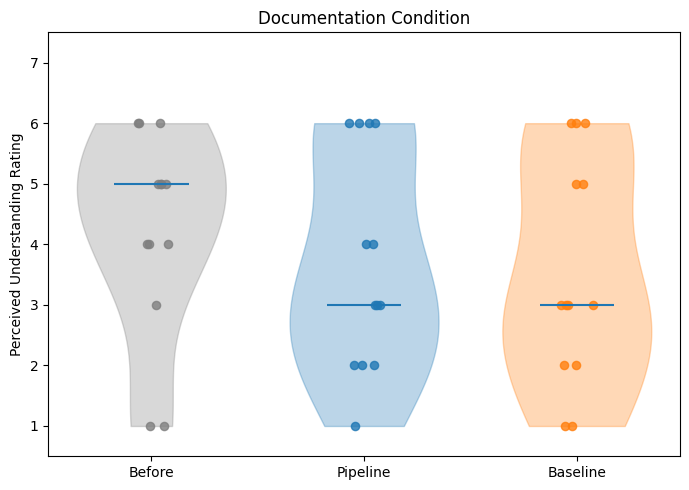

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Colors
BEFORE_COLOR = "#7f7f7f"     # Matplotlib standard gray
PIPELINE_COLOR = "#1f77b4"   # Matplotlib standard blue
BASELINE_COLOR = "#ff7f0e"   # Matplotlib standard orange

# Data
df = pd.DataFrame(data)

conditions = ["Before", "Pipeline", "Baseline"]

condition_colors = [
    BEFORE_COLOR,
    PIPELINE_COLOR,
    BASELINE_COLOR
]

values = [
    df[condition].values
    for condition in conditions
]

positions = np.arange(1, len(conditions) + 1)

# Reproducible jitter
rng = np.random.default_rng(42)


# =========================================================
# 1. VIOLINPLOT + INDIVIDUAL OBSERVATIONS
# =========================================================

fig, ax = plt.subplots(figsize=(7, 5))

parts = ax.violinplot(
    values,
    positions=positions,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Violin colors
for body, color in zip(parts["bodies"], condition_colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.3)

# Individual observations
for i, (condition, color) in enumerate(
    zip(conditions, condition_colors),
    start=1
):

    y = df[condition].values

    jitter = rng.uniform(-0.08, 0.08, size=len(y))
    x = np.full(len(y), i) + jitter

    ax.scatter(
        x,
        y,
        s=35,
        alpha=0.8,
        color=color
    )

ax.set_xticks(positions)
ax.set_xticklabels([
    "Before",
    "Pipeline",
    "Baseline"
])

ax.set_ylabel("Perceived Understanding Rating")
ax.set_ylim(0.5, 7.5)
ax.set_yticks(range(1, 8))

ax.set_title("Documentation Condition")

plt.tight_layout()
plt.show()

### Usability and Usefulness (UMUX-LITE)

In [22]:
# UMUX-LITE data
data = {
    "TN": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "Pipeline": umux_pipeline,
    "Baseline": umux_baseline
}

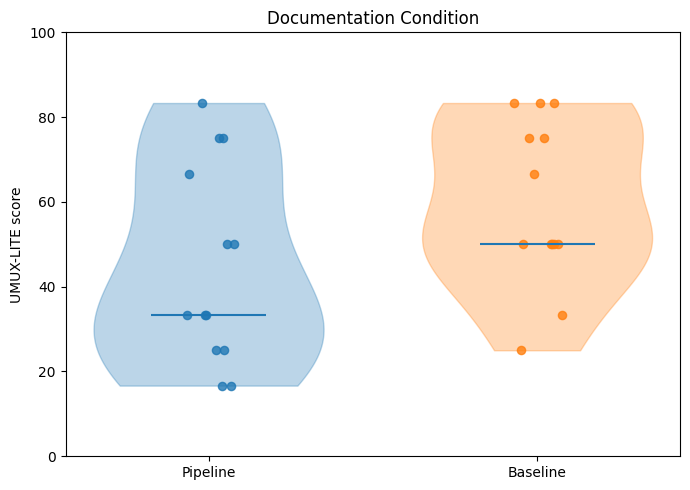

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Colors
PIPELINE_COLOR = "#1f77b4"   # Matplotlib standard blue
BASELINE_COLOR = "#ff7f0e"   # Matplotlib standard orange

# Data
df = pd.DataFrame(data)

conditions = ["Pipeline", "Baseline"]
condition_colors = [PIPELINE_COLOR, BASELINE_COLOR]

values = [
    df[condition].values
    for condition in conditions
]

positions = np.arange(1, len(conditions) + 1)

# Reproducible jitter
rng = np.random.default_rng(42)

# ---------------------------------------------------------
# Violin plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

parts = ax.violinplot(
    values,
    positions=positions,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Violin colors
for body, color in zip(parts["bodies"], condition_colors):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.3)

# Individual participant observations
for i, (condition, color) in enumerate(
    zip(conditions, condition_colors),
    start=1
):

    y = df[condition].values

    jitter = rng.uniform(-0.08, 0.08, size=len(y))
    x = np.full(len(y), i) + jitter

    ax.scatter(
        x,
        y,
        s=35,
        alpha=0.8,
        color=color
    )


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_xticks(positions)
ax.set_xticklabels([
    "Pipeline",
    "Baseline"
])

ax.set_ylabel("UMUX-LITE score")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

ax.set_title("Documentation Condition")

plt.tight_layout()
plt.show()

### Documentation Preference and Recommendation

In [24]:

data = {
    "Pipeline_Item1": prefer_pipeline,
    "Baseline_Item1": prefer_baseline,

    "Pipeline_Item2": recommend_pipeline,
    "Baseline_Item2": recommend_baseline
}

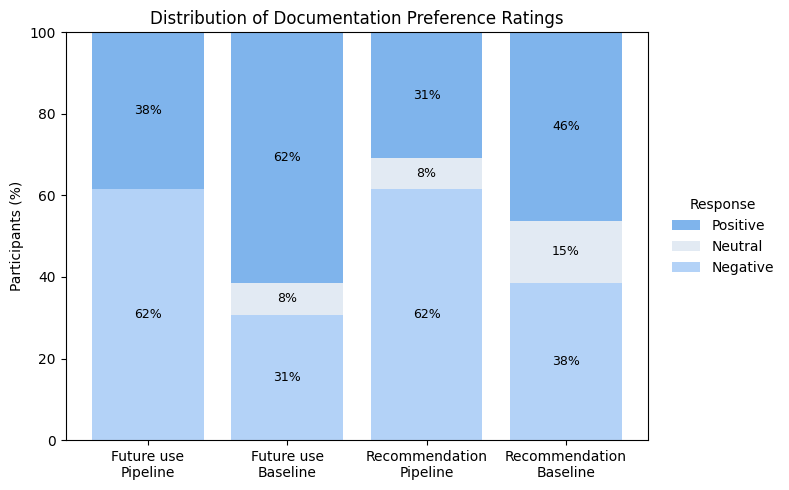

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.DataFrame(data)

# ---------------------------------------------------------
# Classify ratings
# 1-3 = Negative
# 4   = Neutral
# 5-7 = Positive
# ---------------------------------------------------------

def classify(values):
    return {
        "Negative": (values <= 3).sum(),
        "Neutral": (values == 4).sum(),
        "Positive": (values >= 5).sum()
    }

counts = {
    "Future use\nPipeline": classify(df["Pipeline_Item1"]),
    "Future use\nBaseline": classify(df["Baseline_Item1"]),
    "Recommendation\nPipeline": classify(df["Pipeline_Item2"]),
    "Recommendation\nBaseline": classify(df["Baseline_Item2"])
}

plot_df = pd.DataFrame(counts).T

# Convert to percentages
plot_percent = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(len(plot_percent))
colors = {
    "Negative": "#b3d2f7",
    "Neutral": "#e2eaf3",
    "Positive": "#7fb4ec"
}

for category in ["Negative", "Neutral", "Positive"]:

    values = plot_percent[category].values

    bars = ax.bar(
        plot_percent.index,
        values,
        bottom=bottom,
        label=category,
        color=colors[category]
    )

    # Add percentage labels
    for bar, value, base in zip(bars, values, bottom):

        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                base + value / 2,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    bottom += values

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_ylabel("Participants (%)")
#ax.set_xlabel("Documentation condition and preference item")
ax.set_ylim(0, 100)

ax.set_title("Distribution of Documentation Preference Ratings")

handles, labels = ax.get_legend_handles_labels()

# gewünschte Reihenfolge der Legende:
order = [2, 1, 0]

# Legend on the right
ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    title="Response",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()